In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanharode07/webmd-drug-reviews-dataset")

print("Path to dataset files:", path)

/Users/hungnguyen/study - master IT 2024/Term 4/research/research-code/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/hungnguyen/.cache/kagglehub/datasets/rohanharode07/webmd-drug-reviews-dataset/versions/1


In [2]:
# List the head of dataset files
import os
print("Files in dataset directory:", os.listdir(path))
# Load the dataset using pandas
import pandas as pd
dataset_file = os.path.join(path, "webmd.csv")
df = pd.read_csv(dataset_file)
df.head()

Files in dataset directory: ['webmd.csv']


,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount
0,75 or over,Stuffy Nose,9/21/2014,25dph-7.5peh,146724,5,5,I'm a retired physician and of all the meds I ...,5,Male,"Drowsiness, dizziness , dry mouth /nose/thro...",0
1,25-34,Cold Symptoms,1/13/2011,25dph-7.5peh,146724,5,5,cleared me right up even with my throat hurtin...,5,Female,"Drowsiness, dizziness , dry mouth /nose/thro...",1
2,65-74,Other,7/16/2012,warfarin (bulk) 100 % powder,144731,2,3,why did my PTINR go from a normal of 2.5 to ov...,3,Female,,0
3,75 or over,Other,9/23/2010,warfarin (bulk) 100 % powder,144731,2,2,FALLING AND DON'T REALISE IT,1,Female,,0
4,35-44,Other,1/6/2009,warfarin (bulk) 100 % powder,144731,1,1,My grandfather was prescribed this medication ...,1,Male,,1


In [ ]:
# get 1000 rows from df 
df = df.sample(10)
# print to the new file called webmd_1000.csv
# df.to_csv("webmd_1000.csv", index=False)


# df = df[["Age", "Condition", "Drug", "DrugId", "Satisfaction", "Sex", "Reviews"]]

df.isnull().sum()

Age              0
Condition        0
Date             0
Drug             0
DrugId           0
EaseofUse        0
Effectiveness    0
Reviews          1
Satisfaction     0
Sex              0
Sides            0
UsefulCount      0
dtype: int64

In [ ]:
df = df.dropna()

for col in df.columns:
    if df[col].dtype.kind == "O":
        df[col] = df[col].str.strip()

df["Reviews"] = df["Reviews"].astype(str).str.strip()


def satisfaction_to_class(rating: int) -> int:
    """Map WebMD 1–5 satisfaction to 0=Negative, 1=Neutral, 2=Positive."""
    r = int(rating)
    if r <= 2:
        return -1
    if r > 2 and r < 4:
        return 0
    if r >= 4 and r <= 5:
        return 1
    return -1

def filter_anomalies(df: pd.DataFrame, min_review_len: int = 10) -> pd.DataFrame:
    """Remove nulls and very short/uninformative reviews."""
    before = len(df)
    df = df.dropna(subset=["Reviews"]).copy()
    df = df[df["Reviews"].str.strip().str.len() >= min_review_len].copy()
    print(f"\n[3] Anomaly filter: removed {before - len(df)} rows "
          f"(null or < {min_review_len} chars).  Remaining: {len(df):,}")
    return df

def filter_anomalies_report(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    df_filtered = filter_anomalies(df)
    after = len(df_filtered)

    removed = before - after
    removed_pct = (removed / before) * 100 if before > 0 else 0

    print("\n[3] Anomaly Filter Summary")
    print(f"-----------------------------------")
    print(f"Rows before filtering : {before:,}")
    print(f"Rows after filtering  : {after:,}")
    print(f"Rows removed          : {removed:,}")
    print(f"Percent removed       : {removed_pct:.2f}%")
    return df_filtered

df = filter_anomalies_report(df)
len(df)


[3] Anomaly filter: removed 0 rows (null or < 10 chars).  Remaining: 866

[3] Anomaly Filter Summary
-----------------------------------
Rows before filtering : 866
Rows after filtering  : 866
Rows removed          : 0
Percent removed       : 0.00%


866

filter_anomalies_report(df)

In [ ]:
# from transformers import pipeline
# from tqdm import tqdm
# import torch

# # Check if MPS is available
# device = 0 if torch.backends.mps.is_available() else -1
# print("Using device:", "MPS GPU" if device == 0 else "CPU")

# classifier = pipeline(
#     "sentiment-analysis",
#     model="cardiffnlp/twitter-roberta-base-sentiment",
#     device=0,
#     truncation=True,
#     padding=True,
#     max_length=512  
# )

# texts = df["Reviews"].tolist()

# results = []

# for i in tqdm(range(0, len(texts), batch_size)):
#     batch = texts[i:i+batch_size]
#     outputs = classifier(batch, batch_size=batch_size)
#     results.extend(outputs)

#save the results to a csv file 
# results_df = pd.DataFrame(results)
# results_df.to_csv("roberta_results.csv", index=False)

# attach the results to the df

# read the results from the csv file

results_df = pd.read_csv("roberta_results.csv")

results_df["label"] = results_df["label"].map({"LABEL_0": -1, "LABEL_1": 0, "LABEL_2": 1})

results_df = results_df.reset_index(drop=True)
df = df.reset_index(drop=True)

df["score"] = results_df["score"]
df["roberta_results"] = results_df["label"]

# save the df to a csv file
df.to_csv("roberta_results_transformed.csv", index=False)
df.head()



,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount,score,roberta_results
0,13-18,Acne,6/20/2009,retin-a micro gel,16252,5,5,"My acne did get worse at first, and my face go...",4,Female,A brief sensation of warmth or stinging may oc...,9,0.766792,2
1,65-74,Decreased Bone Mass Following Menopause,2/28/2011,atelvia,154925,1,1,aftet takinh the med I was unable to function ...,1,Female,"Stomach / abdominal pain , nausea , vomiting...",14,0.654091,2
2,45-54,Rheumatoid Arthritis,2/3/2013,cimzia 400 mg/2 ml (200 mg/ml x 2) subcutaneou...,150396,5,5,"Love it, nothing seemed to help and I was begi...",5,Female,"Cough , sore throat , stuffy/ runny nose , bu...",17,0.521422,1
3,35-44,Disease of Ovaries with Cysts,3/9/2009,metformin hcl solution,11285,3,2,I was recently diagnosed with PCOS. Started t...,2,Female,"Nausea , vomiting , stomach upset, diarrhe...",4,0.490596,0
4,45-54,Neuropathic Pain,5/31/2009,"oxycodone tablet, oral only",1025,5,5,i was given morphine and other drugs for the p...,5,Male,"Nausea , vomiting , constipation , lighthea...",3,0.811004,0


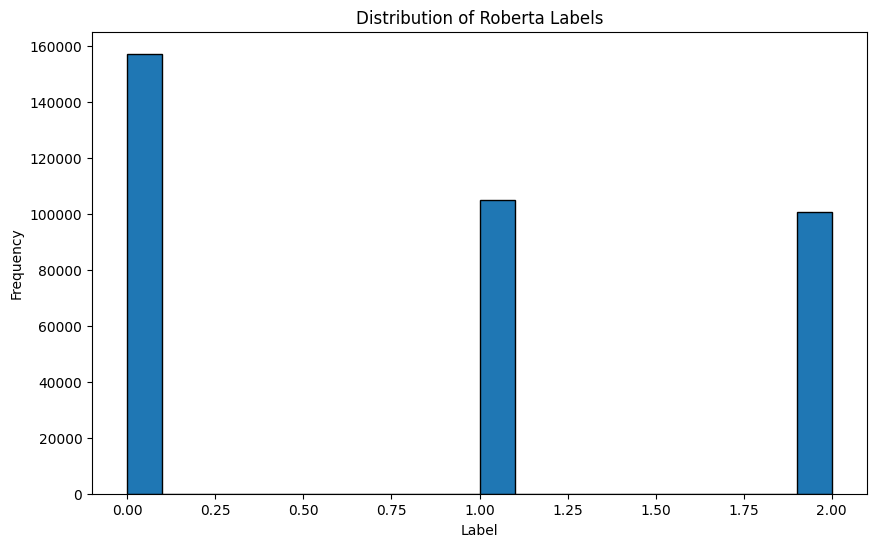

In [6]:
import matplotlib.pyplot as plt

#plot the label distribution
plt.figure(figsize=(10, 6))
plt.hist(results_df["label"], bins=20, edgecolor="black")
plt.title("Distribution of Roberta Labels")
plt.xlabel("Label")
plt.ylabel("Frequency")
plt.show()

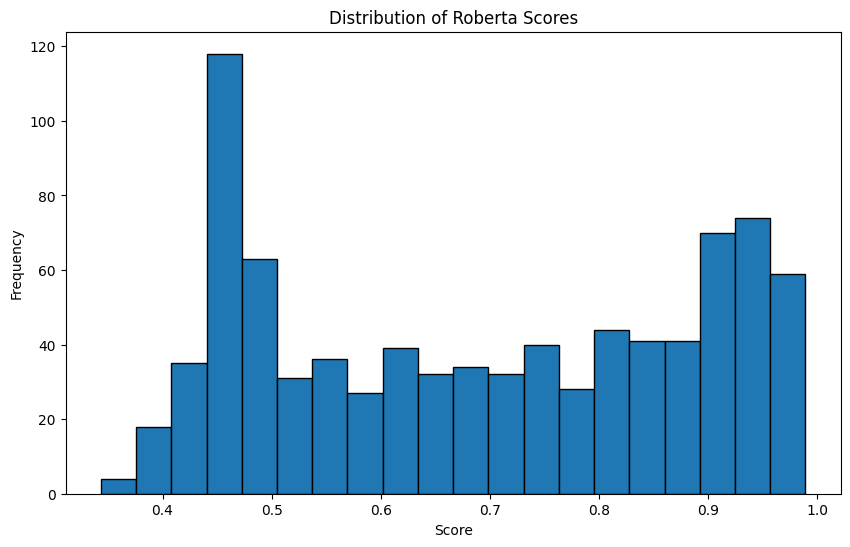

In [7]:
# plot the score of the roberta model
plt.figure(figsize=(10, 6))
plt.hist(df["score"], bins=20, edgecolor="black")
plt.title("Distribution of Roberta Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

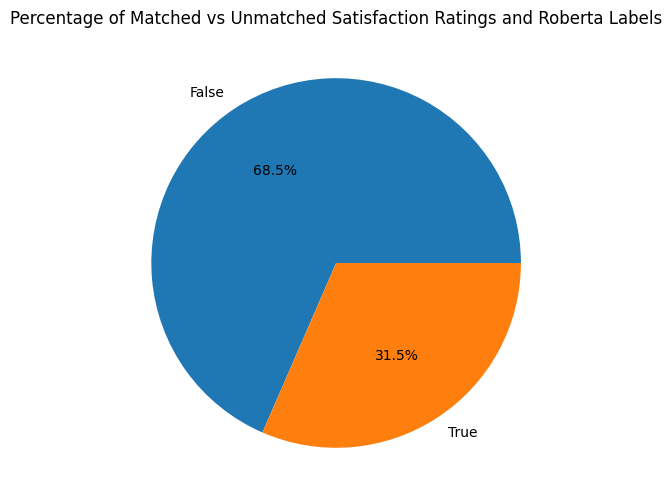

In [8]:
# compare model labels with satisfaction-derived labels

df["label_satisfaction"] = df["Satisfaction"].apply(satisfaction_to_class)

# compare like-for-like strings
df["is_same"] = df["label_satisfaction"] == df["roberta_results"]

# plot percentages using dynamic labels to avoid label-length mismatch
counts = df["is_same"].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(counts.values, labels=counts.index.astype(str), autopct="%1.1f%%")
plt.title("Percentage of Matched vs Unmatched Satisfaction Ratings and Roberta Labels")
plt.show()

